# 03_model_training.ipynb
- Load the feature datasets
- Train a baseline classifier
- Evaluate model performance
- Inspect feature importance

# Import Libraries & Load Data

In [1]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: install xgboost if needed
# !pip install xgboost

# Load prepared features
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()


# Train a Model

## Logistic Regression

In [2]:
logreg = LogisticRegression(max_iter=1000, solver='liblinear')
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)


## Random Forest

In [3]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)


# Evaluate Model

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        37

    accuracy                           1.00        74
   macro avg       1.00      1.00      1.00        74
weighted avg       1.00      1.00      1.00        74

Confusion Matrix:


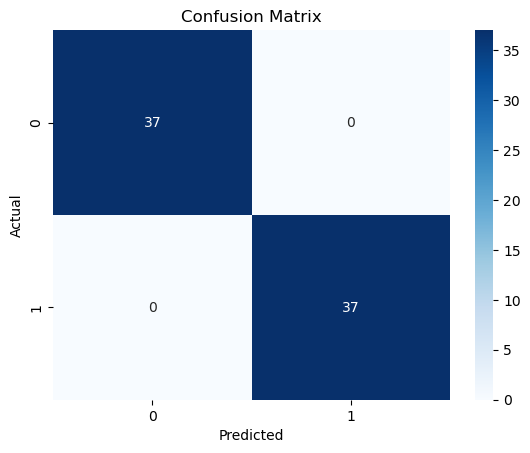

ROC AUC Score: 1.000


In [4]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

roc_score = roc_auc_score(y_test, y_pred)
print(f"ROC AUC Score: {roc_score:.3f}")


#  Feature Importance

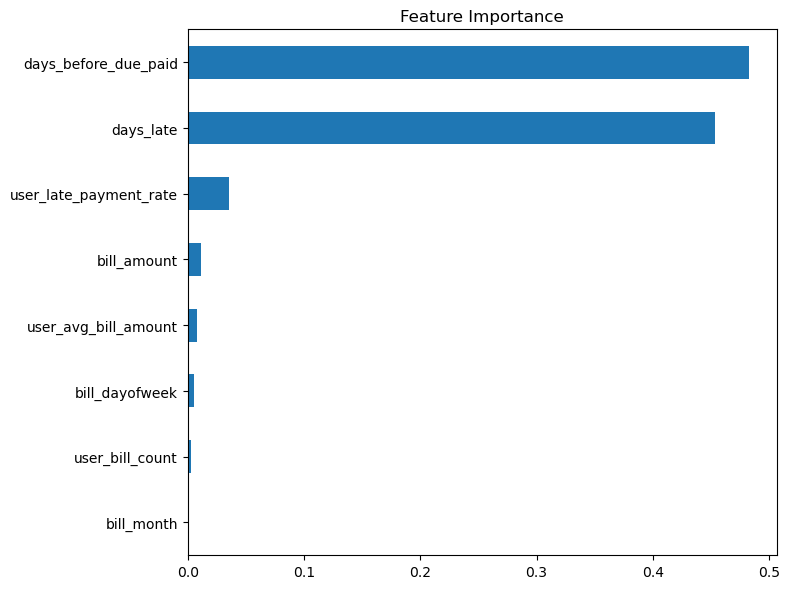

In [5]:
feature_names = X_train.columns
importances = rf.feature_importances_

# Plot
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)
feat_imp.plot(kind="barh", figsize=(8, 6), title="Feature Importance")
plt.tight_layout()
plt.show()


# Save the Trained Model

In [6]:
import joblib

joblib.dump(rf, "model_rf.joblib")
print("Model saved as model_rf.joblib")


Model saved as model_rf.joblib
